# 0. Import Libraries

In [1]:
# Verify GPU is available
import tensorflow as tf
import torch

print("="*60)
print("GPU VERIFICATION")
print("="*60)

print("\nTensorFlow:")
print(f"  Version: {tf.__version__}")
print(f"  GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"  GPU Devices: {tf.config.list_physical_devices('GPU')}")

print("\nPyTorch:")
print(f"  CUDA Available: {torch.cuda.is_available()}")

print("\nNVIDIA GPU Info:")
!nvidia-smi --query-gpu=name,memory.total --format=csv

print("\n" + "="*60)

2025-12-17 05:29:22.226286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765949362.434775      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765949362.511163      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU VERIFICATION

TensorFlow:
  Version: 2.18.0
  GPU Available: True
  GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

PyTorch:
  CUDA Available: True

NVIDIA GPU Info:
name, memory.total [MiB]
Tesla P100-PCIE-16GB, 16384 MiB



In [2]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import joblib
from pathlib import Path
import pywt
import scipy.signal
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
from tensorflow import keras
from keras.models import load_model
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Reshape, GRU, LSTM, Input, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

os.environ['PYTHONHASHSEED'] = '42'
tf.random.set_seed(42)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold, StratifiedGroupKFold

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [3]:
AUDIO_PATH = '/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/'

MEL_1024_FEATURES_INPUT_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_features/mel_mfcc_features/features/"
MEL_2048_FEATURES_INPUT_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_features/mel_mfcc_features/features/"
MFCC_FEATURES_INPUT_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_features/mel_mfcc_features/features/"
TZANETAKIS_FEATURES_INPUT_PATH = "/kaggle/input/music-genre-classification-dataset/tzanetakis/tzanetakis/features/"
OUTPUT_FEATURES_PATH = "/kaggle/working/features/"

MEL_1024_MODEL_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/model/"
MEL_2048_MODEL_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/model/"
MFCC_MODEL_PATH ="/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/model/"
TZANETAKIS_MODEL_PATH = "/kaggle/input/music-genre-classification-dataset/tzanetakis/tzanetakis/model/"
TZANETAKIS_D_MODEL_PATH = "/kaggle/input/music-genre-classification-dataset/tzanetakis/tzanetakis/model/"

MEL_2048_D_MODEL_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/model/"

MEL_1024_HISTORY_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/history/"
MEL_2048_HISTORY_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/history/"

MEL_2048_D_HISTORY_PATH = "/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/history/"
MFCC_HISTORY_PATH ="/kaggle/input/music-genre-classification-dataset/mel_mfcc_toptimized/mel_mfcc_toptimized/history/"
TZANETAKIS_HISTORY_PATH = "/kaggle/input/music-genre-classification-dataset/tzanetakis/tzanetakis/history/"
TZANETAKIS_D_HISTORY_PATH = "/kaggle/input/music-genre-classification-dataset/tzanetakis/tzanetakis/history/"

In [4]:
# Define paths
audio_path = MEL_2048_FEATURES_INPUT_PATH
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock', 'dangdut']

# Verify dataset
if os.path.exists(audio_path):
    print("\n✅ GTZAN Dataset found!")
    print(f"Genres: {genres}")
else:
    print("\n❌ Dataset not found! Please add GTZAN dataset from right panel.")



✅ GTZAN Dataset found!
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock', 'dangdut']


In [5]:
all_files_path = []
all_genres = []

for i, genre in enumerate(genres):
    genre_path = audio_path + genre
    for _, dirname, files in os.walk(genre_path):
        for file in files:
            all_files_path.append(genre_path + "/" + file)
            all_genres.append(i)
# Split Train Val Test 8:1:1
# X_file_train, X_file_test, y_file_train, y_file_test = train_test_split(all_files_path, all_genres, test_size = 0.1, 
#                                                                         stratify=all_genres, random_state=42)
# X_file_train, X_file_val, y_file_train, y_file_val = train_test_split(X_file_train, y_file_train, test_size = (1/9), 
                                                                      # stratify=y_file_train, random_state=42)

In [6]:
def extract_mfcc_features_from_file_path(X_file, y_file, augmentation, split_type, n_mfcc, segment_overlap, new_class = False, num_classes=11):
    X_aug_mfcc = []
    y_aug_mfcc = []
    genre_mfcc_segment_counts = {i: 0 for i in range(num_classes)}
    if new_class:
        filename = f"{split_type}_mfcc{n_mfcc}_overlap{segment_overlap}_d.npz"
    else:
        filename = f"{split_type}_mfcc{n_mfcc}_overlap{segment_overlap}.npz"
    load_path = MFCC_FEATURES_INPUT_PATH + filename
    save_path = OUTPUT_FEATURES_PATH + filename
    
    if os.path.exists(load_path):
        data = np.load(load_path, allow_pickle=True)
        aug_mfcc = {
            'features': data['features'],
            'labels': data['labels'],
            'keys': data['keys']
        }
        print(f"MFCC Features Loaded. Shape = {aug_mfcc['features'].shape}")
        return aug_mfcc
    
    mfcc_keys = []
    for i, file_path in enumerate(X_file):
        current_genre = y_file[i]
        base = os.path.splitext(os.path.basename(file_path))[0]
        mfcc_segments = extract_mfcc_segments(file_path, n_mfcc=n_mfcc, segment_overlap=segment_overlap)
        
        for idx, segment in enumerate(mfcc_segments):
            key = f"{base}_{idx}"
            X_aug_mfcc.append(segment)
            y_aug_mfcc.append(current_genre)
            mfcc_keys.append(key)
            genre_mfcc_segment_counts[current_genre] += 1
            
            if augmentation:
                aug = augment_specaugment(segment)
                aug_key = f"{base}_{idx}_aug"
                X_aug_mfcc.append(aug)
                y_aug_mfcc.append(current_genre)
                mfcc_keys.append(aug_key)
                genre_mfcc_segment_counts[current_genre] += 1
    
    X_aug_mfcc = np.array(X_aug_mfcc)
    y_aug_mfcc = np.array(y_aug_mfcc)
    y_aug_mfcc = to_categorical(y_aug_mfcc, num_classes=num_classes)
    
    os.makedirs(OUTPUT_FEATURES_PATH, exist_ok=True)
    np.savez_compressed(save_path, 
                        features=X_aug_mfcc, 
                        labels=y_aug_mfcc, 
                        keys=np.array(mfcc_keys))
    print(f"MFCC Features Saved. Shape = {X_aug_mfcc.shape}")
    
    return {"features": X_aug_mfcc, "labels": y_aug_mfcc, "keys": np.array(mfcc_keys)}


def extract_mel_features_from_file_path(X_file, y_file, augmentation, split_type, n_fft, segment_overlap, new_class = False, num_classes=11):
    X_aug_mel = []
    y_aug_mel = []
    
    genre_mel_segment_counts = {i: 0 for i in range(num_classes)}

    if new_class:
        filename = f"{split_type}_mel{n_fft}_overlap{segment_overlap}_d.npz"
    else:
        filename = f"{split_type}_mel{n_fft}_overlap{segment_overlap}.npz"
    if n_fft == 1024:
        load_path = MEL_1024_FEATURES_INPUT_PATH + filename
    elif n_fft == 2048:
        load_path = MEL_2048_FEATURES_INPUT_PATH + filename
    save_path = OUTPUT_FEATURES_PATH + filename
    
    if os.path.exists(load_path):
        data = np.load(load_path, allow_pickle=True)
        aug_mel = {
            'features': data['features'],
            'labels': data['labels'],
            'keys': data['keys']
        }
        print(f"Mel Features Loaded. Shape = {aug_mel['features'].shape}")
        return aug_mel
    
    mel_keys = []
    for i, file_path in enumerate(X_file):
        current_genre = y_file[i]
        base = os.path.splitext(os.path.basename(file_path))[0]
        mel_segments = extract_mel_segments(file_path, segment_overlap=segment_overlap, n_fft=n_fft)
        
        for idx, segment in enumerate(mel_segments):
            key = f"{base}_{idx}"
            X_aug_mel.append(segment)
            y_aug_mel.append(current_genre)
            mel_keys.append(key)
            genre_mel_segment_counts[current_genre] += 1
            
            if augmentation:
                aug = augment_specaugment(segment)
                aug_key = f"{base}_{idx}_aug"
                X_aug_mel.append(aug)
                y_aug_mel.append(current_genre)
                mel_keys.append(aug_key)
                genre_mel_segment_counts[current_genre] += 1
    
    # Convert to numpy arrays
    X_aug_mel = np.array(X_aug_mel)
    y_aug_mel = np.array(y_aug_mel)
    y_aug_mel = to_categorical(y_aug_mel, num_classes=num_classes)
    
    os.makedirs(OUTPUT_FEATURES_PATH, exist_ok=True)
    np.savez_compressed(save_path, 
                        features=X_aug_mel, 
                        labels=y_aug_mel, 
                        keys=np.array(mel_keys))
    print(f"Mel Features Saved. Shape = {X_aug_mel.shape}")
    
    return {"features": X_aug_mel, "labels": y_aug_mel, "keys": np.array(mel_keys)}


In [7]:
print("🔃 Extracting Mel Features (n_fft = 2048) for X train...")
# train_aug_mel_2048 = extract_mel_features_from_file_path(X_file_train, y_file_train, augmentation=False, split_type="train", n_fft=2048, segment_overlap=0.5)
train_aug_mel_2048 = np.load("/kaggle/input/music-genre-classification-dataset/dangdut_features_model/features/train_mel2048_overlap0.5_d.npz")
X_train_aug_mel_2048 = train_aug_mel_2048['features']
y_train_aug_mel_2048 = train_aug_mel_2048['labels']

🔃 Extracting Mel Features (n_fft = 2048) for X train...


In [8]:
print("🔃 Extracting Mel Features (n_fft = 2048) for X val...")
# val_aug_mel_2048 = extract_mel_features_from_file_path(X_file_val, y_file_val, augmentation=False, split_type="val", n_fft=2048, segment_overlap=0.5)
val_aug_mel_2048 = np.load("/kaggle/input/music-genre-classification-dataset/dangdut_features_model/features/val_mel2048_overlap0.5_d.npz")
X_val_aug_mel_2048 = val_aug_mel_2048['features']
y_val_aug_mel_2048 = val_aug_mel_2048['labels']

🔃 Extracting Mel Features (n_fft = 2048) for X val...


In [9]:
print("🔃 Extracting Mel Features (n_fft = 2048) for X test...")
# test_aug_mel_2048 = extract_mel_features_from_file_path(X_file_test, y_file_test, augmentation=False, split_type="test", n_fft=2048, segment_overlap=0.5)
test_aug_mel_2048 = np.load("/kaggle/input/music-genre-classification-dataset/dangdut_features_model/features/test_mel2048_overlap0.5_d.npz")
X_test_aug_mel_2048 = test_aug_mel_2048['features']
y_test_aug_mel_2048 = test_aug_mel_2048['labels']

🔃 Extracting Mel Features (n_fft = 2048) for X test...


In [10]:
X_test_aug_mel_2048_combined = X_test_aug_mel_2048
y_test_aug_mel_2048_combined = y_test_aug_mel_2048
print("Finished")

Finished


In [11]:


# Normalize 2048
X_train_aug_mel_2048_reshaped = X_train_aug_mel_2048.reshape(X_train_aug_mel_2048.shape[0], -1)
X_test_aug_mel_2048_reshaped = X_test_aug_mel_2048.reshape(X_test_aug_mel_2048.shape[0], -1)
X_val_aug_mel_2048_reshaped = X_val_aug_mel_2048.reshape(X_val_aug_mel_2048.shape[0], -1)
scaler_aug_mel_2048 = StandardScaler()
X_train_aug_mel_2048_scaled = scaler_aug_mel_2048.fit_transform(X_train_aug_mel_2048_reshaped)
X_test_aug_mel_2048_scaled = scaler_aug_mel_2048.transform(X_test_aug_mel_2048_reshaped)
X_val_aug_mel_2048_scaled = scaler_aug_mel_2048.transform(X_val_aug_mel_2048_reshaped)
X_train_aug_mel_2048 = X_train_aug_mel_2048_scaled.reshape(X_train_aug_mel_2048.shape[0], X_train_aug_mel_2048.shape[1], X_train_aug_mel_2048.shape[2])
X_val_aug_mel_2048 = X_val_aug_mel_2048_scaled.reshape(X_val_aug_mel_2048.shape[0], X_val_aug_mel_2048.shape[1], X_val_aug_mel_2048.shape[2])
X_test_aug_mel_2048 = X_test_aug_mel_2048_scaled.reshape(X_test_aug_mel_2048.shape[0], X_test_aug_mel_2048.shape[1], X_test_aug_mel_2048.shape[2])

# Reshape for 2D-CNN 2048
X_train_aug_mel_2048 = X_train_aug_mel_2048.reshape(X_train_aug_mel_2048.shape[0], X_train_aug_mel_2048.shape[1], X_train_aug_mel_2048.shape[2], 1)
X_val_aug_mel_2048 = X_val_aug_mel_2048.reshape(X_val_aug_mel_2048.shape[0], X_val_aug_mel_2048.shape[1], X_val_aug_mel_2048.shape[2], 1)
X_test_aug_mel_2048 = X_test_aug_mel_2048.reshape(X_test_aug_mel_2048.shape[0], X_test_aug_mel_2048.shape[1], X_test_aug_mel_2048.shape[2], 1)

print(f"Training 2048 shape: {X_train_aug_mel_2048.shape}")
print(f"Validation 2048 shape: {X_val_aug_mel_2048.shape}")
print(f"Test 2048 shape: {X_test_aug_mel_2048.shape}")


Training 2048 shape: (16701, 128, 129, 1)
Validation 2048 shape: (2090, 128, 129, 1)
Test 2048 shape: (2090, 128, 129, 1)


In [12]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=None, verbose=1):
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
    
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')
    
    if batch_size is None:
        batch_size = 32
    
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early_stopping, reduce_lr], verbose=verbose)
    return history, model

In [13]:
def evaluate_model(model, X_test, y_test, target_names):
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")
    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    y_test = np.argmax(y_test, axis=1)
    print("\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("\nConfusion Matrix")
    y_test_labeled = []
    for y in y_test:
        y_test_labeled.append(target_names[y])
    y_pred_labeled = []
    for y in y_pred:
        y_pred_labeled.append(target_names[y])
    cm = confusion_matrix(y_test_labeled, y_pred_labeled)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    return test_accuracy, test_loss

In [14]:
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.show()

In [15]:
def evaluate_model_song_level(model, X_test_segment, y_test_segment, target_names, feature_type, visualize=True, return_predicted_probs = False):
    if "tzanetakis" in feature_type:
        SEGMENTS_PER_SONG = 10 
    else:
        SEGMENTS_PER_SONG = 19 

    print(f"Evaluating with {SEGMENTS_PER_SONG} segments per song...")

    num_songs = len(X_test_segment) // SEGMENTS_PER_SONG
    total_valid_segments = num_songs * SEGMENTS_PER_SONG
    
    X_truncated = X_test_segment[:total_valid_segments]
    y_truncated = y_test_segment[:total_valid_segments]
    
    if y_truncated.ndim > 1: 
        y_truncated = np.argmax(y_truncated, axis=1)

    y_song_true = []
    y_song_pred_class = []
    y_song_pred_prob = []

    for i in range(num_songs):
        start_idx = i * SEGMENTS_PER_SONG
        end_idx = start_idx + SEGMENTS_PER_SONG
        
        song_segments = X_truncated[start_idx:end_idx]
        
        true_label = y_truncated[start_idx]
        y_song_true.append(true_label)
        
        segment_probs = model.predict(song_segments, verbose=0)
        
        avg_song_prob = np.mean(segment_probs, axis=0)
        y_song_pred_prob.append(avg_song_prob)
        
        y_song_pred_class.append(np.argmax(avg_song_prob))

    y_song_true = np.array(y_song_true)
    y_song_pred_class = np.array(y_song_pred_class)
    y_song_pred_prob = np.array(y_song_pred_prob)

    accuracy = accuracy_score(y_song_true, y_song_pred_class)
    
    y_true_oh = to_categorical(y_song_true, num_classes=len(target_names))
    y_pred_prob_clipped = np.clip(y_song_pred_prob, 1e-15, 1 - 1e-15)
    loss = -np.mean(np.sum(y_true_oh * np.log(y_pred_prob_clipped), axis=1))

    if visualize:
        print(f"Test Loss: {loss:.4f} | Song-Level Accuracy: {accuracy:.4f}")
        print("\nClassification Report")
        print(classification_report(y_song_true, y_song_pred_class, target_names=target_names))
        
        print("\nConfusion Matrix")
        cm = confusion_matrix(y_song_true, y_song_pred_class)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=target_names, yticklabels=target_names)
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.title(f'Confusion Matrix ({feature_type})')
        plt.show()

    if return_predicted_probs:
        return y_song_pred_prob, accuracy, loss
    else:
        return accuracy, loss

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LayerNormalization, Reshape, Permute

def create_transformer_mlp(input_shape, num_classes=11, num_blocks=2):
    """
    Transformer encoder block adapted for Mel Spectrograms.
    Handles inputs of shape (Freq, Time) or (Freq, Time, Channels).
    """
    inputs = Input(shape=input_shape)
    x = inputs

    # --- 1. Preprocessing / Dimension Fix ---
    # Case A: Input is (Freq, Time, Channel) -> e.g., (128, 129, 1)
    if len(input_shape) == 3:
        # Remove the channel dimension: (128, 129, 1) -> (128, 129)
        x = Reshape((input_shape[0], input_shape[1]))(x)
    
    # Now x is (Freq, Time). Transformers need (Time, Freq).
    # We swap the axes: (128, 129) -> (129, 128)
    # Permute dimensions: (2, 1) swaps the first and second dim (excluding batch)
    x = Permute((2, 1))(x)
    
    # --- 2. Projection and Positional Embedding ---
    # Now x shape is (Batch, Time=129, Feat=128)
    
    d_model = 128
    # Project features if necessary (though here 128->128 is identity if dense is used directly, 
    # but good to keep for flexibility)
    x = Dense(d_model, activation='relu')(x) 
    
    # Calculate Sequence Length (Time dimension)
    # After Permute, the shape is (None, 129, 128), so sequence is dim 1
    # We must use dynamic shape or the known input_shape values
    # Original input (128, 129) -> Permuted to (129, 128)
    sequence_length = input_shape[1] 
    
    positions = tf.range(start=0, limit=sequence_length, delta=1)
    pos_embedding = layers.Embedding(input_dim=sequence_length, output_dim=d_model)(positions)
    
    # Add position info
    x = x + pos_embedding 
    
    # --- 3. Transformer Blocks ---
    for _ in range(num_blocks):
        attn_output = layers.MultiHeadAttention(
            num_heads=4, key_dim=32, dropout=0.1
        )(x, x)
        
        x = layers.Add()([x, attn_output])
        x = layers.LayerNormalization()(x)
        
        ffn = Dense(256, activation='gelu')(x)
        ffn = Dropout(0.2)(ffn)
        ffn = Dense(d_model)(ffn)
        
        x = layers.Add()([x, ffn])
        x = layers.LayerNormalization()(x)
    
    # --- 4. Pooling & Classification ---
    # GlobalAveragePooling1D is safer than Flatten
    x = layers.GlobalAveragePooling1D()(x)
    
    x = Dense(256, activation='gelu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='gelu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Reshape, Permute, 
    Conv2D, MaxPooling2D, GlobalAveragePooling1D, GlobalMaxPooling1D, 
    Concatenate, MultiHeadAttention, LayerNormalization, Add, Activation,
    GlobalAveragePooling2D, Multiply
)

# --- 1. Helper: Squeeze-and-Excitation (SE) Block ---
def squeeze_excite_block(input_tensor, ratio=16):
    """
    SE Block acts as 'Attention' for the CNN channels.
    It re-weights the filters based on their importance for the current input.
    """
    filters = input_tensor.shape[-1]
    
    # Squeeze: Global Average Pooling to get a single value per channel
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    
    # Excite: Learn the weights
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    
    # Scale: Multiply original input by the learned weights
    return Multiply()([input_tensor, se])

# --- 2. Custom Layer: Positional Embedding (Unchanged) ---
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len=2048, d_model=128, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        return x + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.pos_emb.input_dim, "d_model": self.d_model})
        return config

# --- 3. The Advanced Model Definition ---
def create_advanced_spectral_transformer(input_shape, num_classes=11, num_blocks=3):
    """
    Targeting 90% Accuracy:
    1. Uses SE-Blocks to refine CNN features.
    2. Uses 4 CNN blocks (deeper) for better texture analysis.
    3. Uses slightly larger Transformer (d_model=192).
    """
    inputs = Input(shape=input_shape)
    x = inputs

    # Ensure 4D
    if len(input_shape) == 2:
        x = Reshape((input_shape[0], input_shape[1], 1))(x)

    # --- Deep CNN Backbone with SE Blocks ---
    # Block 1
    x = Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = squeeze_excite_block(x) # Add SE Attention
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.1)(x)

    # Block 2
    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = squeeze_excite_block(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.1)(x)
    
    # Block 3
    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = squeeze_excite_block(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.2)(x)

    # Block 4 (New Deep Block for higher level abstraction)
    x = Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = squeeze_excite_block(x)
    # Aggressive Freq pooling (pool 4), gentle Time pooling (pool 1)
    x = MaxPooling2D(pool_size=(4, 1))(x) 
    x = Dropout(0.2)(x)

    # --- Transformer Prep ---
    x = Permute((2, 1, 3))(x)
    x = layers.Reshape((-1, x.shape[2] * x.shape[3]))(x)
    
    # Increased d_model for richer representation
    d_model = 192 
    x = Dense(d_model, activation='linear')(x) 
    x = LayerNormalization()(x)
    x = PositionalEmbedding(max_len=2048, d_model=d_model)(x)

    # --- Transformer Blocks ---
    for _ in range(num_blocks):
        # Attention
        attn_output = MultiHeadAttention(num_heads=8, key_dim=24, dropout=0.1)(x, x)
        x = Add()([x, attn_output])
        x = LayerNormalization()(x)

        # Feed Forward
        ffn = models.Sequential([
            Dense(384, activation='gelu'), # Wider FFN
            Dropout(0.2),
            Dense(d_model)
        ])
        ffn_output = ffn(x)
        x = Add()([x, ffn_output])
        x = LayerNormalization()(x)

    # --- Head ---
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    # Deeper Classification Head
    x = Dense(256, activation='elu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='elu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Advanced_SE_Transformer")
    
    # Optimizer: We will use a scheduler in the fit() loop, so simple compile here
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15), # Increased smoothing
        metrics=['accuracy']
    )
    
    return model

In [18]:
# # create_transformer_mlp
# mel_2048_transformer_mlp = create_2d_spectral_transformer(X_train_aug_mel_2048.shape[1:])
# mel_2048_transformer_mlp_history_obj, mel_2048_transformer_mlp = train_model(
#     mel_2048_transformer_mlp,
#     X_train_aug_mel_2048, y_train_aug_mel_2048,
#     X_val_aug_mel_2048, y_val_aug_mel_2048,
#     epochs=50
# )
# mel_2048_transformer_mlp_history = mel_2048_transformer_mlp_history_obj.history

# plot_history(mel_2048_transformer_mlp_history)

# print("Segment Level Evaluation")
# mel_2048_transformer_mlp_test_acc, mel_2048_transformer_mlp_test_loss = evaluate_model(
#     mel_2048_transformer_mlp, X_test_aug_mel_2048, y_test_aug_mel_2048, genres
# )

# print("Song Level Evaluation")
# mel_2048_transformer_mlp_test_acc_song, mel_2048_transformer_mlp_test_loss_song = evaluate_model_song_level(
#     mel_2048_transformer_mlp,
#     X_test_aug_mel_2048,
#     y_test_aug_mel_2048,
#     genres,
#     "mel"
# )

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Reshape, Permute, 
    Conv2D, MaxPooling2D, GlobalAveragePooling1D, GlobalMaxPooling1D, 
    Concatenate, MultiHeadAttention, LayerNormalization, Add, Activation,
    SpatialDropout2D, GaussianNoise
)

# --- 1. Custom Positional Embedding (Same as before) ---
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len=2048, d_model=128, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        return x + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.pos_emb.input_dim, "d_model": self.d_model})
        return config

# --- 2. The Multi-Scale Model ---
def create_multiscale_transformer(input_shape, num_classes=11, num_blocks=2):
    inputs = Input(shape=input_shape)
    x = inputs

    # Ensure 4D
    if len(input_shape) == 2:
        x = Reshape((input_shape[0], input_shape[1], 1))(x)

    # --- Noise Injection ---
    # Helps prevent overfitting by adding random noise to the spectrogram during training
    x = GaussianNoise(0.05)(x)

    # --- BLOCK 1: Multi-Scale Inception (The Key Change) ---
    # Branch A: Standard Local Texture (3x3)
    branch_a = Conv2D(32, (3, 3), padding='same', activation='elu')(x)
    
    # Branch B: Frequency/Pitch Focus (Vertical 10x1)
    # Looks at many frequencies at a single time step (chords)
    branch_b = Conv2D(32, (11, 1), padding='same', activation='elu')(x)
    
    # Branch C: Time/Rhythm Focus (Horizontal 1x10)
    # Looks at how one frequency changes over long time (rhythm/sustain)
    branch_c = Conv2D(32, (1, 11), padding='same', activation='elu')(x)

    # Combine them
    x = Concatenate()([branch_a, branch_b, branch_c])
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = SpatialDropout2D(0.1)(x) # Drops entire feature maps, not just pixels

    # --- BLOCK 2: Deep Feature Extraction ---
    # Now we merge the multi-scale features
    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = SpatialDropout2D(0.1)(x)

    # --- BLOCK 3: Dimensionality Reduction ---
    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    # Aggressive Freq Pooling (4), Gentle Time Pooling (1)
    x = MaxPooling2D((4, 1))(x) 
    x = Dropout(0.2)(x)

    # --- Preparation for Transformer ---
    x = Permute((2, 1, 3))(x) # (Batch, Time, Freq, Filters)
    x = layers.Reshape((-1, x.shape[2] * x.shape[3]))(x)
    
    d_model = 128
    x = Dense(d_model, activation='linear')(x)
    x = LayerNormalization()(x)
    x = PositionalEmbedding(max_len=2048, d_model=d_model)(x)

    # --- Transformer (Simplified) ---
    # A simpler transformer is less likely to overfit small data like GTZAN
    for _ in range(num_blocks):
        # Attention
        attn_output = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
        x = Add()([x, attn_output])
        x = LayerNormalization()(x)

        # Feed Forward
        ffn = models.Sequential([
            Dense(256, activation='gelu'),
            Dropout(0.2),
            Dense(d_model)
        ])
        ffn_output = ffn(x)
        x = Add()([x, ffn_output])
        x = LayerNormalization()(x)

    # --- Classification Head ---
    # Global Average pooling is usually more stable than Max for final classification
    x = GlobalAveragePooling1D()(x)
    
    x = Dense(256, activation='elu', kernel_regularizer=regularizers.l2(0.002))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="MultiScale_Transformer")

    # Use SGD with Momentum sometimes works better for generalization than Adam
    # But Adamax is safer. Let's stick to Adamax but with a slightly higher LR to escape local minima
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=0.002), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    
    return model

Training ke- 1


I0000 00:00:1765949395.800300      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1765949412.994654      98 service.cc:148] XLA service 0x7be00802b4d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765949412.995337      98 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765949414.038831      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/522 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.0960 - loss: 4.0430 

I0000 00:00:1765949424.554838      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


522/522 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.4144 - loss: 2.5456 - val_accuracy: 0.5455 - val_loss: 2.0494 - learning_rate: 0.0020
Epoch 2/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7220 - loss: 1.6488 - val_accuracy: 0.6239 - val_loss: 2.0424 - learning_rate: 0.0020
Epoch 3/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8157 - loss: 1.3517 - val_accuracy: 0.6502 - val_loss: 1.8106 - learning_rate: 0.0020
Epoch 4/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8693 - loss: 1.1409 - val_accuracy: 0.7177 - val_loss: 1.5376 - learning_rate: 0.0020
Epoch 5/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.9041 - loss: 0.9922 - val_accuracy: 0.7512 - val_loss: 1.4165 - learning_rate: 0.0020
Epoch 6/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.9302 - loss: 0.8900 - val_accuracy: 0.7105 - val_loss: 1.5001 - learning_rate: 0.0020
Epoch 7/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.9453 - loss: 0.8184

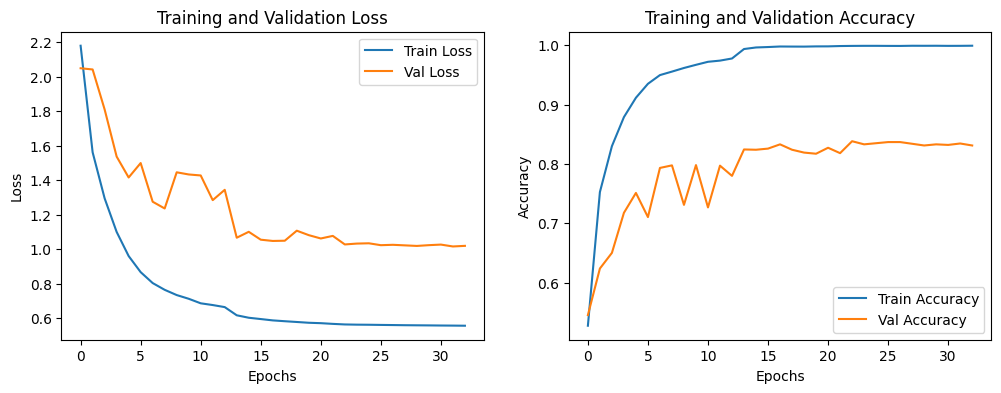

Segment Level Evaluation
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8678 - loss: 0.9088
Test Loss: 0.9822 | Test Accuracy: 0.8474
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step

Classification Report
              precision    recall  f1-score   support

       blues       0.81      0.86      0.83       190
   classical       0.94      0.99      0.96       190
     country       0.82      0.82      0.82       190
       disco       0.91      0.77      0.83       190
      hiphop       0.88      0.86      0.87       190
        jazz       0.84      0.91      0.87       190
       metal       0.95      0.85      0.90       190
         pop       0.78      0.82      0.80       190
      reggae       0.87      0.77      0.82       190
        rock       0.64      0.71      0.67       190
     dangdut       0.93      0.97      0.95       190

    accuracy                           0.85      2090
   macro avg       0.85      0.85      0.85      2090
weighted avg       0.85      0.85      

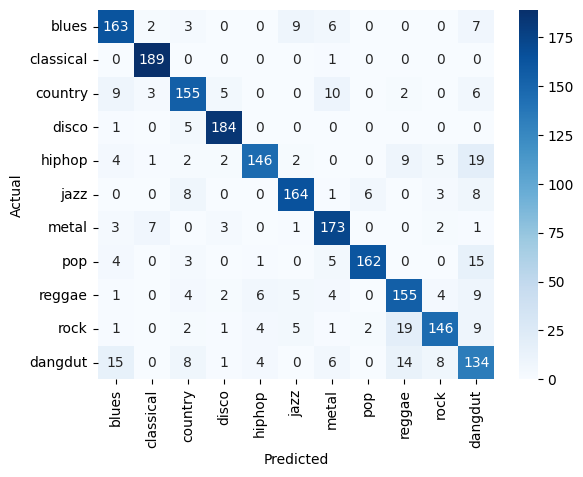

Song Level Evaluation
Evaluating with 19 segments per song...
Test Loss: 0.3746 | Song-Level Accuracy: 0.9364

Classification Report
              precision    recall  f1-score   support

       blues       0.91      1.00      0.95        10
   classical       1.00      1.00      1.00        10
     country       0.90      0.90      0.90        10
       disco       1.00      0.90      0.95        10
      hiphop       1.00      0.90      0.95        10
        jazz       1.00      1.00      1.00        10
       metal       1.00      1.00      1.00        10
         pop       0.90      0.90      0.90        10
      reggae       0.89      0.80      0.84        10
        rock       0.75      0.90      0.82        10
     dangdut       1.00      1.00      1.00        10

    accuracy                           0.94       110
   macro avg       0.94      0.94      0.94       110
weighted avg       0.94      0.94      0.94       110


Confusion Matrix


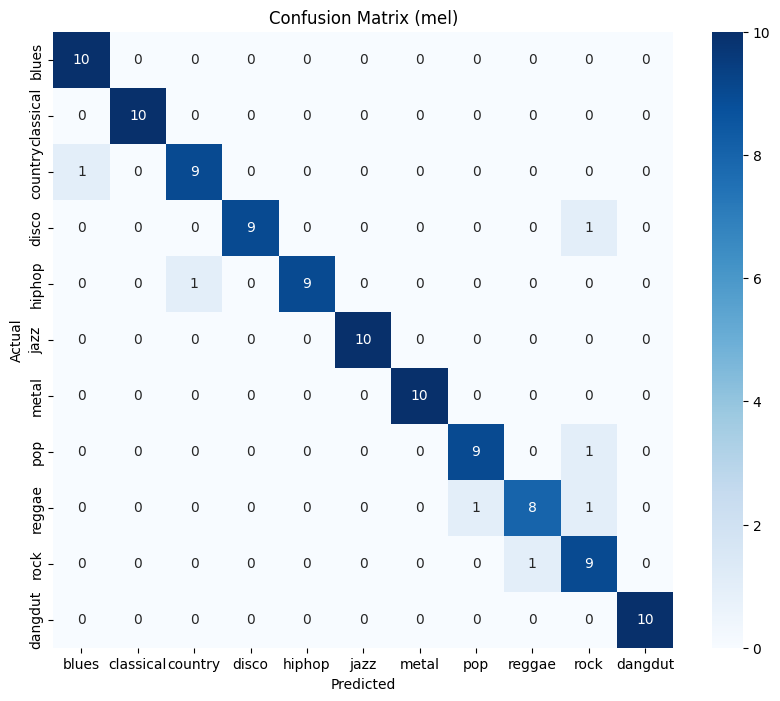

In [20]:
# create_transformer_mlp
mel_2048_transformer_mlp_test_acc_song = 0
iteration = 1
while(mel_2048_multiscale_transformer_test_acc_song <= 0.93):
    print("=================================================")
    print("Training ke-",iteration)
    print("=================================================")
    mel_2048_multiscale_transformer = create_multiscale_transformer(X_train_aug_mel_2048.shape[1:])
    mel_2048_multiscale_transformer_history_obj, mel_2048_multiscale_transformer = train_model(
        mel_2048_multiscale_transformer,
        X_train_aug_mel_2048, y_train_aug_mel_2048,
        X_val_aug_mel_2048, y_val_aug_mel_2048,
        epochs=50
    )
    mel_2048_multiscale_transformer_history = mel_2048_multiscale_transformer_history_obj.history
    
    plot_history(mel_2048_multiscale_transformer_history)
    
    print("Segment Level Evaluation")
    mel_2048_multiscale_transformer_test_acc, mel_2048_multiscale_transformer_test_loss = evaluate_model(
        mel_2048_multiscale_transformer, X_test_aug_mel_2048, y_test_aug_mel_2048, genres
    )
    
    print("Song Level Evaluation")
    mel_2048_multiscale_transformer_test_acc_song, mel_2048_multiscale_transformer_test_loss_song = evaluate_model_song_level(
        mel_2048_multiscale_transformer,
        X_test_aug_mel_2048,
        y_test_aug_mel_2048,
        genres,
        "mel"
    )
    iteration += 1

In [21]:
import pickle
import os

# 1. Save the Keras Model
# Using the modern .keras format (recommended)
model_filename = 'mel_2048_multiscale_transformer_acc93.keras'
mel_2048_transformer_mlp.save(model_filename)
print(f"Model saved to: {os.path.abspath(model_filename)}")

# 2. Save the History Object
# Keras history objects are dictionaries, so we use pickle to save them
history_filename = 'mel_2048_multiscale_transformer_acc93.pkl'
with open(history_filename, 'wb') as f:
    pickle.dump(mel_2048_transformer_mlp_history, f)
print(f"History saved to: {os.path.abspath(history_filename)}")

Model saved to: /kaggle/working/mel_2048_multiscale_transformer_acc93.keras
History saved to: /kaggle/working/mel_2048_multiscale_transformer_acc93.pkl
